In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1) Load some offline training data
# Adjust this path if needed (use one of your existing train npy files)
project_dir = "/home/jessica/shape_control_DLO_2/"
env_dim = "2D"

state_path = project_dir + f"data/train_data/{env_dim}/state_0.npy"
state = np.load(state_path).astype("float32")   # shape [T, state_dim]
print("state shape:", state.shape)

state shape: (120000, 117)


In [16]:
import sys
from pathlib import Path

# Point to the scripts directory
proj_root = Path("/home/jessica/shape_control_DLO_2")
scripts_dir = proj_root / "ws_dlo" / "src" / "dlo_manipulation_pkg" / "scripts"

# Add scripts dir to Python path
sys.path.append(str(scripts_dir))

# Now you can import directly by filename (without .py)
from utils.state_index import I
from GNN_offline_rot import get_graph_data  # or GNN_offline if that's the file name

numFPs = 10


In [7]:
# 3) Helper: extract raw fps + ends positions from world frame
def extract_positions(s):
    fps = s[I.fps_pos_idx].reshape(numFPs, 3)          # [10,3]
    left_end = s[I.left_end_pos_idx]                  # [3]
    right_end = s[I.right_end_pos_idx]                # [3]
    return fps, left_end, right_end


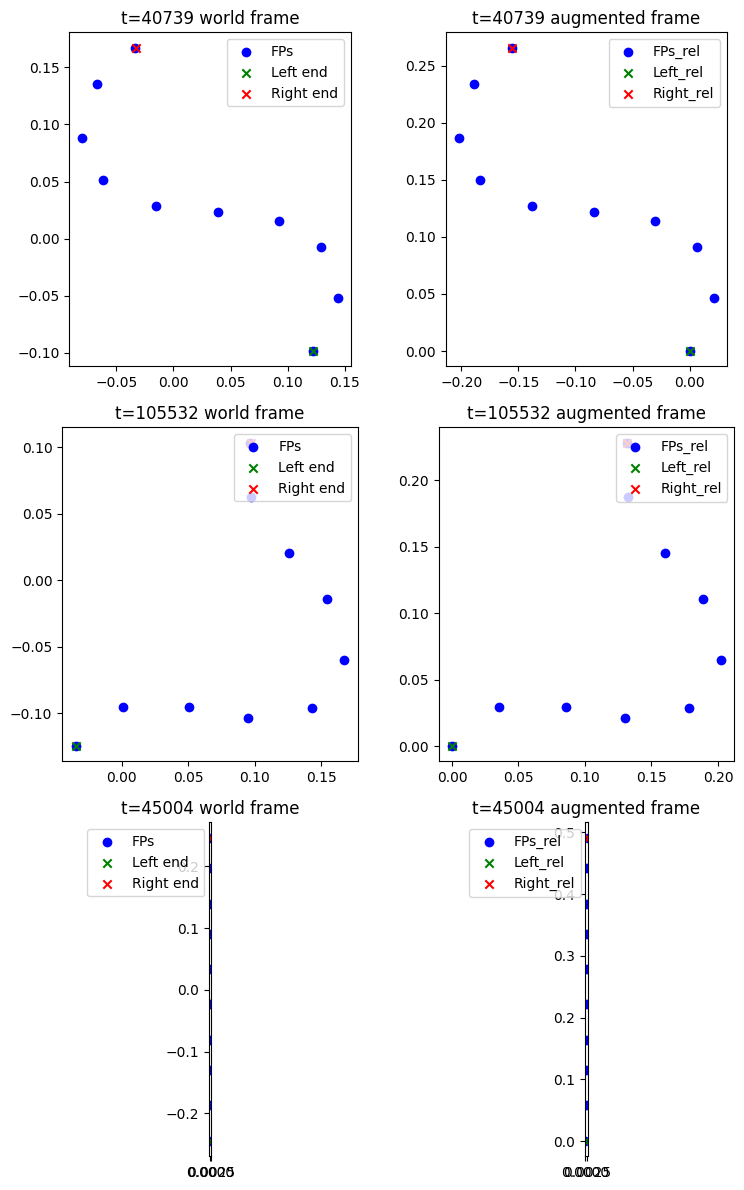

In [15]:
# 4) Pick a few random timesteps
np.random.seed(0)
idxs = np.random.choice(state.shape[0], size=3, replace=False)

fig, axes = plt.subplots(len(idxs), 2, figsize=(8, 4*len(idxs)))

for row, t in enumerate(idxs):
    s = state[t]
    fps, left_end, right_end = extract_positions(s)

    # ---- World frame (left column) ----
    ax_w = axes[row, 0] if len(idxs) > 1 else axes[0]
    ax_w.scatter(fps[:, 0], fps[:, 1], c="b", label="FPs")
    ax_w.scatter(left_end[0], left_end[1], c="g", marker="x", label="Left end")
    ax_w.scatter(right_end[0], right_end[1], c="r", marker="x", label="Right end")
    ax_w.set_title(f"t={t} world frame")
    ax_w.set_aspect("equal")
    ax_w.legend(loc="upper right")

    # ---- Augmented frame (right column) ----
    # Length: use I.length_idx directly
    length_scalar = s[I.length_idx]              # scalar or 0‑D array
    length = np.array([length_scalar], dtype=np.float32)  # shape [1]

    # State input as in training
    state_input = s[I.state_input_idx].reshape(1, -1)     # [1, 44]

    import torch
    state_input_t = torch.tensor(state_input, dtype=torch.float32)
    length_t = torch.tensor(length, dtype=torch.float32)

    # Your modified get_graph_data with origin shift
    g = get_graph_data(state_input_t, length_t, numFPs=numFPs)

    node_xyz_rel = g.all_pos_xyz.numpy()   # [numFPs+2, 3]
    # order in get_graph_data: [left_end, fps(0..9), right_end]
    left_rel = node_xyz_rel[0]
    fps_rel = node_xyz_rel[1:-1]
    right_rel = node_xyz_rel[-1]

    ax_r = axes[row, 1] if len(idxs) > 1 else axes[1]
    ax_r.scatter(fps_rel[:, 0], fps_rel[:, 1], c="b", label="FPs_rel")
    ax_r.scatter(left_rel[0], left_rel[1], c="g", marker="x", label="Left_rel")
    ax_r.scatter(right_rel[0], right_rel[1], c="r", marker="x", label="Right_rel")
    ax_r.set_title(f"t={t} augmented frame")
    ax_r.set_aspect("equal")
    ax_r.legend(loc="upper right")

plt.tight_layout()
plt.show()


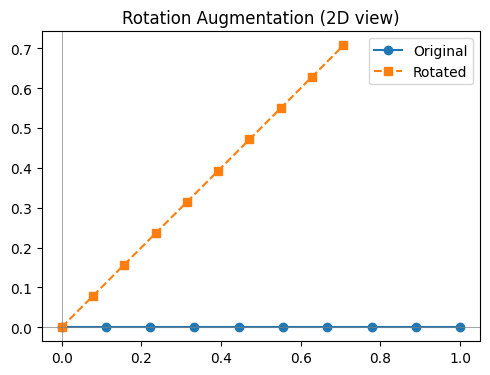

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def demo_rotation_augmentation():
    # Simple straight rope
    num_fps = 10
    x = np.linspace(0, 1.0, num_fps)
    y = np.zeros(num_fps)
    pts = np.stack([x, y], axis=1)  # (N,2)

    # Random rotation
    theta = np.deg2rad(45)  # e.g. 45 deg for demo
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    pts_rot = (R @ pts.T).T

    plt.figure(figsize=(5,5))
    plt.plot(pts[:,0], pts[:,1], 'o-', label='Original')
    plt.plot(pts_rot[:,0], pts_rot[:,1], 's--', label='Rotated')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.gca().set_aspect('equal', 'box')
    plt.title('Rotation Augmentation (2D view)')
    plt.legend()
    plt.tight_layout()
    plt.show()

demo_rotation_augmentation()


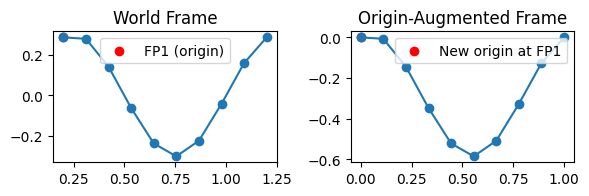

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def demo_origin_augmentation():
    num_fps = 10
    # Rope in some world frame
    x = np.linspace(0.2, 1.2, num_fps)
    y = 0.3 * np.sin(2 * np.pi * x)
    pts_world = np.stack([x, y], axis=1)

    # Origin at FP1
    origin = pts_world[0:1, :]        # FP1
    pts_rel = pts_world - origin      # shift

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.plot(pts_world[:,0], pts_world[:,1], 'o-')
    plt.scatter(origin[0,0], origin[0,1], c='red', label='FP1 (origin)')
    plt.title('World Frame')
    plt.gca().set_aspect('equal', 'box')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(pts_rel[:,0], pts_rel[:,1], 'o-')
    plt.scatter(0, 0, c='red', label='New origin at FP1')
    plt.title('Origin-Augmented Frame')
    plt.gca().set_aspect('equal', 'box')
    plt.legend()

    plt.tight_layout()
    plt.show()

demo_origin_augmentation()


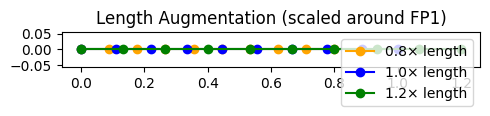

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def demo_length_augmentation():
    num_fps = 10
    # Nominal rope (1.0 m) along x
    x = np.linspace(0, 1.0, num_fps)
    y = np.zeros(num_fps)
    pts = np.stack([x, y], axis=1)

    origin = pts[0:1, :]  # FP1

    scales = [0.8, 1.0, 1.2]
    colors = ['orange', 'blue', 'green']
    labels = ['0.8× length', '1.0× length', '1.2× length']

    plt.figure(figsize=(5,5))
    for s, c, lab in zip(scales, colors, labels):
        pts_rel = pts - origin
        pts_scaled = origin + s * pts_rel
        plt.plot(pts_scaled[:,0], pts_scaled[:,1], 'o-', color=c, label=lab)

    plt.gca().set_aspect('equal', 'box')
    plt.title('Length Augmentation (scaled around FP1)')
    plt.legend()
    plt.tight_layout()
    plt.show()

demo_length_augmentation()


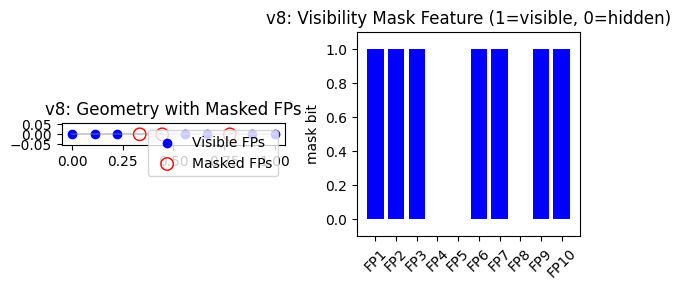

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def demo_masking_v8():
    num_fps = 10
    # Simple rope
    x = np.linspace(0, 1.0, num_fps)
    y = np.zeros(num_fps)
    pts = np.stack([x, y], axis=1)

    # Example mixed masking: contiguous {3,4} and random {7}
    visible = np.ones(num_fps, dtype=bool)
    hidden_indices = [3,4,7]
    visible[hidden_indices] = False

    plt.figure(figsize=(6,3))

    # (a) Geometry with hidden FPs
    plt.subplot(1,2,1)
    plt.plot(pts[:,0], pts[:,1], '-', color='gray', alpha=0.4)
    plt.scatter(pts[visible,0], pts[visible,1], c='blue', label='Visible FPs')
    plt.scatter(pts[~visible,0], pts[~visible,1], facecolors='none',
                edgecolors='red', s=80, label='Masked FPs')
    plt.title('v8: Geometry with Masked FPs')
    plt.gca().set_aspect('equal', 'box')
    plt.legend()

    # (b) Mask feature visualization
    plt.subplot(1,2,2)
    idx = np.arange(num_fps)
    mask_values = visible.astype(int)  # 1 visible, 0 hidden
    plt.bar(idx, mask_values, color=['blue' if v else 'red' for v in visible])
    plt.xticks(idx, [f'FP{i+1}' for i in idx], rotation=45)
    plt.ylim(-0.1, 1.1)
    plt.ylabel('mask bit')
    plt.title('v8: Visibility Mask Feature (1=visible, 0=hidden)')

    plt.tight_layout()
    plt.show()

demo_masking_v8()


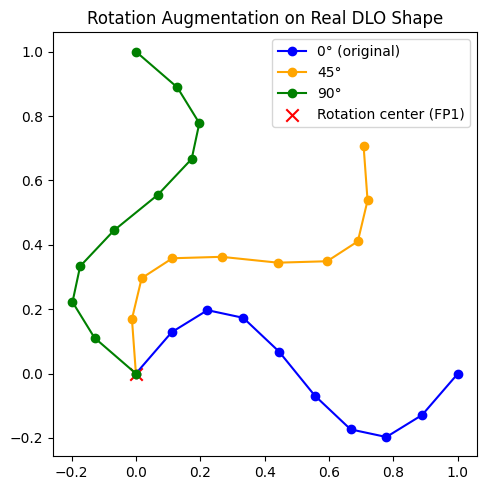

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def demo_rotation_augmentation_from_shape(fps_pos):
    """
    fps_pos: (N,3) numpy array of FP positions in world frame (you can pass any DLO state)
             Only x,y are used for 2D plotting.
    """
    pts = fps_pos[:, :2]          # (N,2) take x,y
    N = pts.shape[0]

    # Choose a rotation center: e.g. mean or FP1
    center = pts[0:1, :]          # use FP1 as center
    pts_rel = pts - center

    # Example rotations
    angles_deg = [0, 45, 90]
    colors = ['blue', 'orange', 'green']
    labels = ['0° (original)', '45°', '90°']

    plt.figure(figsize=(5,5))
    for ang, c, lab in zip(angles_deg, colors, labels):
        theta = np.deg2rad(ang)
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])
        pts_rot = (R @ pts_rel.T).T + center
        plt.plot(pts_rot[:,0], pts_rot[:,1], 'o-', color=c, label=lab)

    plt.scatter(center[0,0], center[0,1], c='red', marker='x', s=80, label='Rotation center (FP1)')
    plt.gca().set_aspect('equal', 'box')
    plt.title('Rotation Augmentation on Real DLO Shape')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example usage with a curved DLO:
def example_curved_shape():
    num_fps = 10
    s = np.linspace(0, 1.0, num_fps)
    x = s
    y = 0.2 * np.sin(2 * np.pi * s)
    z = np.zeros_like(x)
    fps_pos = np.stack([x, y, z], axis=1)
    return fps_pos

fps_pos_example = example_curved_shape()
demo_rotation_augmentation_from_shape(fps_pos_example)


Saved figure to: dlo_occlusion_example.png


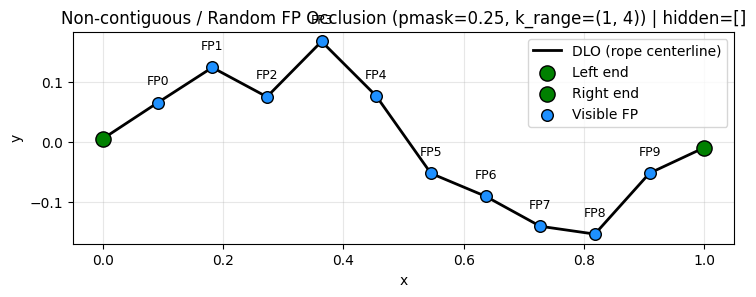

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def occlusion_case_random_visual(pmask=0.25, numFPs=10, k_range=(1, 4), seed=None):
    """
    Mimics your occlusion_case_random() sampling logic:
    - With probability pmask, hide k FPs where k ∈ [k_range[0], k_range[1]]
    - Otherwise hide none.
    Returns fp_visible_mask shape (numFPs,) with 1=visible, 0=hidden.
    """
    rng = np.random.default_rng(seed)

    fp_visible_mask = np.ones(numFPs, dtype=np.float32)

    if rng.random() < pmask:
        k = rng.integers(k_range[0], k_range[1] + 1)
        hidden = rng.choice(numFPs, size=k, replace=False)
        fp_visible_mask[hidden] = 0.0

    return fp_visible_mask


def make_dlo_points(numFPs=10, seed=0):
    """
    Creates a simple 2D DLO-like curve with:
    - left end
    - numFPs feature points along the rope
    - right end
    """
    rng = np.random.default_rng(seed)

    # Parameter along rope
    t = np.linspace(0, 1, numFPs + 2)

    # A smooth curve + small noise (2D)
    x = t
    y = 0.15 * np.sin(2 * np.pi * t) + 0.03 * rng.normal(size=t.shape)

    pts = np.stack([x, y], axis=1)  # shape: (numFPs+2, 2)
    left_end = pts[0]
    fps = pts[1:-1]     # (numFPs,2)
    right_end = pts[-1]
    return left_end, fps, right_end, pts


def plot_dlo_with_occlusion(
    pmask=0.25,
    numFPs=10,
    k_range=(1, 4),
    dlo_seed=0,
    occ_seed=None,
    save_path=None
):
    left_end, fps, right_end, pts_all = make_dlo_points(numFPs=numFPs, seed=dlo_seed)
    fp_mask = occlusion_case_random_visual(pmask=pmask, numFPs=numFPs, k_range=k_range, seed=occ_seed)

    fig, ax = plt.subplots(figsize=(9, 3))

    # Rope polyline (always visible)
    ax.plot(pts_all[:, 0], pts_all[:, 1], color="black", linewidth=2, label="DLO (rope centerline)")

    # Endpoints
    ax.scatter([left_end[0]], [left_end[1]], s=120, color="green", edgecolor="black", zorder=5, label="Left end")
    ax.scatter([right_end[0]], [right_end[1]], s=120, color="green", edgecolor="black", zorder=5, label="Right end")

    # Feature points: visible = solid blue, hidden = dotted red circle
    visible_idx = np.where(fp_mask > 0.5)[0]
    hidden_idx = np.where(fp_mask <= 0.5)[0]

    if len(visible_idx) > 0:
        ax.scatter(
            fps[visible_idx, 0], fps[visible_idx, 1],
            s=70, color="dodgerblue", edgecolor="black", zorder=6,
            label="Visible FP"
        )

    if len(hidden_idx) > 0:
        # draw dotted outline circles around where the FP would be
        ax.scatter(
            fps[hidden_idx, 0], fps[hidden_idx, 1],
            s=140, facecolors="none", edgecolors="red",
            linewidths=2, linestyles="dotted", zorder=7,
            label="Occluded FP (dotted outline)"
        )

    # Annotate FP indices
    for i in range(numFPs):
        ax.text(fps[i, 0], fps[i, 1] + 0.03, f"FP{i}", fontsize=9, ha="center")

    # Title includes the occlusion parameters
    hidden_list = hidden_idx.tolist()
    ax.set_title(f"Non-contiguous / Random FP Occlusion (pmask={pmask}, k_range={k_range}) | hidden={hidden_list}")

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)
        print("Saved figure to:", save_path)

    plt.show()


if __name__ == "__main__":
    # Run multiple times with different seeds to show different non-contiguous patterns
    plot_dlo_with_occlusion(
        pmask=0.25,       # same idea as your training occlusion probability
        numFPs=10,
        k_range=(1, 4),   # same as your code
        dlo_seed=2,
        occ_seed=7,
        save_path="dlo_occlusion_example.png"
    )
